# PCA

In [87]:
#import libraries 

import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns

#
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [29]:
#load the data
data = sns.load_dataset('iris')
data

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,virginica
146,6.3,2.5,5.0,1.9,virginica
147,6.5,3.0,5.2,2.0,virginica
148,6.2,3.4,5.4,2.3,virginica


In [75]:
#convert species to numeric/ encode
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
data['species'] = le.fit_transform(data['species'])

data

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,2
146,6.3,2.5,5.0,1.9,2
147,6.5,3.0,5.2,2.0,2
148,6.2,3.4,5.4,2.3,2


## PCA Steps

* 1. **Drop the label**

In [77]:
#drop the label
X = data.drop('species', axis=1)
y = data['species']

0      0
1      0
2      0
3      0
4      0
      ..
145    2
146    2
147    2
148    2
149    2
Name: species, Length: 150, dtype: int64

* 2. **Scale the features**

In [31]:
#Always scale the data before applying pca
sc = StandardScaler()
X_scaled = sc.fit_transform(X)

In [36]:
#instantiate pca and apply it on features(X) only
pca = PCA(n_components=3)

x_pca = pca.fit_transform(X_scaled)

In [37]:
#check shape
print(X.shape)
print(x_pca.shape)


(150, 4)
(150, 3)


In [38]:
x_pca

array([[-2.26470281,  0.4800266 ,  0.12770602],
       [-2.08096115, -0.67413356,  0.23460885],
       [-2.36422905, -0.34190802, -0.04420148],
       [-2.29938422, -0.59739451, -0.09129011],
       [-2.38984217,  0.64683538, -0.0157382 ],
       [-2.07563095,  1.48917752, -0.02696829],
       [-2.44402884,  0.0476442 , -0.3354704 ],
       [-2.23284716,  0.22314807,  0.0886955 ],
       [-2.33464048, -1.11532768, -0.14507686],
       [-2.18432817, -0.46901356,  0.25376557],
       [-2.1663101 ,  1.04369065,  0.2686811 ],
       [-2.32613087,  0.13307834, -0.09375924],
       [-2.2184509 , -0.72867617,  0.23091124],
       [-2.6331007 , -0.96150673, -0.18079608],
       [-2.1987406 ,  1.86005711,  0.472901  ],
       [-2.26221453,  2.68628449, -0.03052661],
       [-2.2075877 ,  1.48360936,  0.00534409],
       [-2.19034951,  0.48883832,  0.04421532],
       [-1.898572  ,  1.40501879,  0.37434327],
       [-2.34336905,  1.12784938, -0.13263047],
       [-1.914323  ,  0.40885571,  0.421

In [40]:
pca_df = pd.DataFrame(x_pca, columns= ['pc1', 'pc2', 'pc3'])

pca_df

,pc1,pc2,pc3
0,-2.264703,0.480027,0.127706
1,-2.080961,-0.674134,0.234609
2,-2.364229,-0.341908,-0.044201
3,-2.299384,-0.597395,-0.091290
4,-2.389842,0.646835,-0.015738
...,...,...,...
145,1.870503,0.386966,-0.256274
146,1.564580,-0.896687,0.026371
147,1.521170,0.269069,-0.180178
148,1.372788,1.011254,-0.933395


In [64]:
pca.singular_values_

array([20.92306556, 11.7091661 ,  4.69185798])

In [50]:
# get the % variance explained by each principal componet(PC), apply on instantiated pca component
for i, ratio in enumerate(pca.explained_variance_ratio_):
    print(f'{i +1}: {ratio:.2%}')

1: 72.96%
2: 22.85%
3: 3.67%


<Axes: xlabel='pc1', ylabel='pc2'>

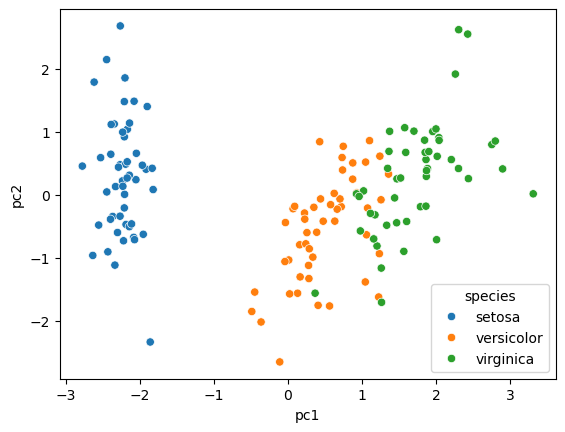

In [61]:
#visualize the pc

sns.scatterplot(x= pca_df["pc1"], y=pca_df["pc2"], hue=data['species'])

In [68]:
# get 3d visualization
import plotly.express as px

In [70]:
fig = px.scatter_3d(pca_df, x= 'pc1', y='pc2', z='pc3', color ="rtarget", title="PCA 3D Visualization" )
fig.show()

C:\Users\DELL\Anaconda3\Lib\site-packages\plotly\io\_renderers.py:51: UserWarning:

Plotly version >= 6 requires Jupyter Notebook >= 7 but you have 6.5.4 installed.
 To upgrade Jupyter Notebook, please run `pip install notebook --upgrade`.



In [79]:
#create random forest classifier

#get the pc features
X_pc = pca_df.drop('pc3', axis=1)

In [83]:
#split data into train and test set
x_train, x_test, y_train, y_test = train_test_split(X_pc, y, test_size=.3, stratify=y, random_state=42)

In [84]:
#create the model

rf = RandomForestClassifier(max_depth= 3, random_state=42)
rf.fit(x_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,3
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [85]:
rf.score(x_train, y_train)

0.9428571428571428

In [88]:
#

y_pred = rf.predict(x_test)

accuracy_score(y_test, y_pred)

0.8666666666666667

In [89]:
rf.feature_importances_

array([0.74462396, 0.25537604])